In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [2]:
original_df=pd.read_csv("Final_test_data.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.shape

(4466, 15)

In [5]:
df

,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login
0,1-25,0,1,1,1,66666.0,1,0,176.5,1,4,2,1,1,420
1,26-100,0,2,1,0,60.0,0,1,0.6,1,0,0,0,0,441
2,101-500,0,2,1,0,60.0,0,1,1.4,1,0,0,0,0,441
3,26-100,0,1,1,0,50.0,0,1,178.8,3,0,0,1,0,441
4,26-100,0,2,1,0,60.0,0,1,138.8,1,0,0,1,0,1796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,1-25,0,1,1,0,35.0,0,0,1.2,1,3,1,2,3,331
4462,1-25,0,1,1,0,147.0,0,0,0.0,1,3,3,5,1,0
4463,26-100,0,1,1,0,50.0,0,0,1.2,1,0,0,0,0,330
4464,1-25,0,1,1,0,49.0,0,0,0.0,1,2,2,2,1,0


In [6]:
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)

def log1p_transform(X):
    return np.log1p(X)

binary_columns = ['is_premium','subscription_status','jobma_catcher_status','is_unlimited','plan_type']

numerical_columns = ['sub_users','wallet_amount', 'subscription_count','invitations','pre_recorded_kit_counts',
                     'number_of_jobs_posted', 'pre_rec_interview_taken','days_since_login']

categorical_columns = ['company_size']
ordinal_columns = ['subscription_sum']

# Binary pipeline
binary_pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_binary, validate=False)),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_categorical, validate=False)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal pipeline
ordinal_pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(log1p_transform, validate=False))
])

# Numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_numerical, validate=False)),
    ('imputer', SimpleImputer(strategy='mean'))
])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('bin', binary_pipeline, binary_columns),
    ('cat', categorical_pipeline, categorical_columns),
    ('ord', ordinal_pipeline, ordinal_columns),
    ('num', numerical_pipeline, numerical_columns),
])

# Final pipeline with scaling
pipeline = Pipeline([('preprocessing', preprocessor),
                     ('scaler', StandardScaler())])

In [7]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4466, 19])

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [9]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
batch_size = 16

In [10]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=19, bias=True)
  )
)

In [11]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/50, Loss: 0.0968
Epoch 4/50, Loss: 0.0616
Epoch 6/50, Loss: 0.0515
Epoch 8/50, Loss: 0.0602
Epoch 10/50, Loss: 0.0301
Epoch 12/50, Loss: 0.0356
Epoch 14/50, Loss: 0.0325
Epoch 16/50, Loss: 0.0220
Epoch 18/50, Loss: 0.0281
Epoch 20/50, Loss: 0.0463
Epoch 22/50, Loss: 0.0154
Epoch 24/50, Loss: 0.0147
Epoch 26/50, Loss: 0.0180
Epoch 28/50, Loss: 0.0268
Epoch 30/50, Loss: 0.0265
Epoch 32/50, Loss: 0.0192
Epoch 34/50, Loss: 0.0253
Epoch 36/50, Loss: 0.0196
Epoch 38/50, Loss: 0.0164
Epoch 40/50, Loss: 0.0279
Epoch 42/50, Loss: 0.0852
Epoch 44/50, Loss: 0.0176
Epoch 46/50, Loss: 0.0193
Epoch 48/50, Loss: 0.0150
Epoch 50/50, Loss: 0.0122


In [12]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4466, 64)

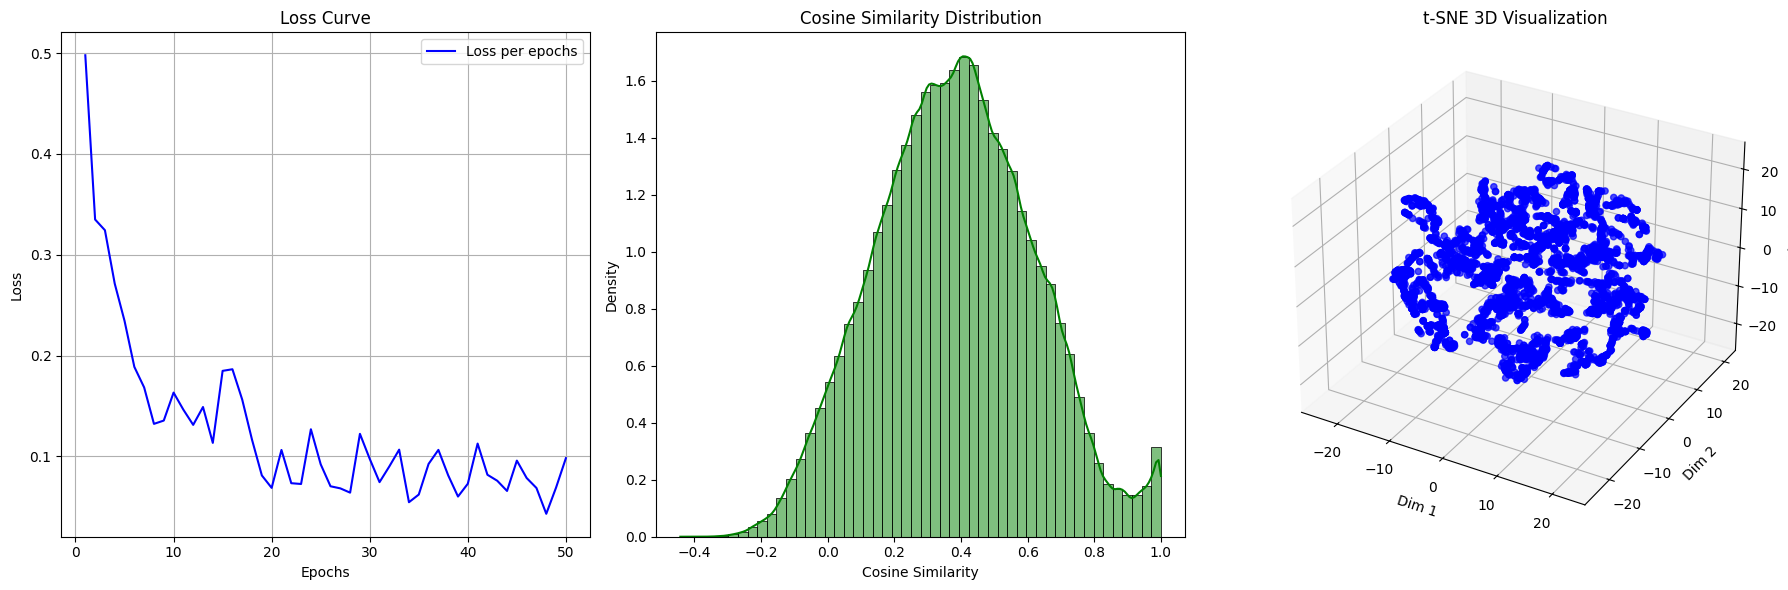

In [13]:
#Loss Curve
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Loss per epochs', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

#Cosine Similarity Histogram
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

#t-SNE in 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c='blue', alpha=0.7)
ax3.set_title('t-SNE 3D Visualization')
ax3.set_xlabel('Dim 1')
ax3.set_ylabel('Dim 2')
ax3.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

In [14]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
        
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [15]:
sample_dict = { 'company_size': '101-500',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations': 0,
                'pre_recorded_kit_counts': 0,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_sum': 138.8,
                'days_since_login': 1256}
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,3034,101-500,0,2,1,0,60.0,0,1,138.8,1,0,0,1,0,1775,0.976748
1,2956,101-500,0,2,1,0,60.0,0,1,138.8,1,0,0,1,0,1793,0.976545
2,3872,101-500,0,2,1,0,60.0,0,1,69.4,2,0,0,0,0,1675,0.967752
3,5477,101-500,0,2,1,0,60.0,0,1,208.2,1,0,0,0,0,1387,0.962090
4,5527,101-500,0,2,1,0,60.0,0,1,208.2,1,0,0,0,0,1382,0.961677


In [16]:
sample_dict2= { 'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 25,
                'pre_rec_interview_taken': 15,
                'subscription_sum': 117.8,
                'days_since_login': '1641-5000'}

In [17]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,5828,26-100,0,2,1,1,60.0,0,1,208.2,1,13,3,10,10,1222,0.928605
1,5346,26-100,0,2,1,1,60.0,0,1,6.9,1,1,1,10,0,1409,0.892982
2,5123,26-100,0,2,1,0,60.0,0,1,2.8,1,3,0,14,0,1459,0.886852
3,6462,26-100,0,2,1,0,60.0,0,1,208.2,1,5,2,4,1,1110,0.883245
4,5045,26-100,0,2,1,0,60.0,0,1,2.8,1,0,0,11,0,1465,0.866997


In [18]:
sample_dictt= { 'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 11,
                'wallet_amount': 101.0,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 15,
                'pre_rec_interview_taken': 15,
                'subscription_sum': 208.8,
                'days_since_login': 1000}

recommend_from_sample_dict(sample_dictt, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,8715,26-100,0,2,1,13,60.0,0,0,1.8,1,0,1,1,0,855,0.853094
1,5416,101-500,0,2,1,9,60.0,0,1,347.1,1,12,1,1,1,1387,0.842458
2,6042,26-100,1,2,1,10,60.0,0,0,11.8,4,11,2,3,3,1094,0.818493
3,7005,26-100,0,2,1,1,60.0,0,0,36.0,4,0,0,0,0,1079,0.807431
4,7350,26-100,0,1,1,1,60.0,0,0,44.2,3,0,1,0,0,1066,0.806549


In [19]:
sample_dict4= { 'company_size': '1-25',
                'is_premium': 1,
                'subscription_status': 1,
                'jobma_catcher_status': 1,
                'sub_users': 5,
                'wallet_amount': 500000.0,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 4,
                'pre_rec_interview_taken': 25,
                'subscription_sum': 347.1,
                'days_since_login': 1000}
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,9757,500-1000,1,1,1,11,500000.0,1,0,480.6,13,102,7,12,47,527,0.764047
1,8197,1-25,1,1,1,3,60.0,0,0,71.3,5,2,1,1,1,981,0.745284
2,6017,500-1000,1,1,1,10,1860.0,0,0,56.7,11,15,6,9,5,469,0.708431
3,7977,1-25,0,2,1,2,60.0,0,0,72.5,7,0,0,0,0,1019,0.697183
4,6847,1-25,0,1,1,1,60.0,0,0,363.1,6,0,0,0,0,1081,0.674799


In [20]:
sample_dict5= { 'company_size': '1-25',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 16,
                'wallet_amount': 500000.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 5,
                'invitations':45,
                'pre_recorded_kit_counts': 58,
                'number_of_jobs_posted': 428,
                'pre_rec_interview_taken': 25725,
                'subscription_sum': 300000,
                'days_since_login': 500}
recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,7151,26-100,0,2,1,1,60.0,0,1,347.1,1,444,22,3,348,885,0.883364
1,6110,1-25,0,2,1,1,60.0,0,1,208.2,1,487,3,1,183,970,0.773296
2,6139,1-25,0,2,1,3,88.0,0,1,523.6,2,983,82,12,468,668,0.711614
3,6411,26-100,0,2,1,0,60.0,0,1,208.2,1,295,6,5,102,417,0.679145
4,5868,1-25,1,1,1,4,60.0,0,1,2637.9,8,614,41,11,375,1005,0.676777


# Saving model, preprocessor and embeddings

In [21]:
import joblib

In [22]:
joblib.dump(pipeline, 'pipeline.pkl')

['pipeline.pkl']

In [23]:
torch.save(model.state_dict(), "autoencoder.pth")

In [24]:
np.save("embeddings.npy", embeddings_np)

In [25]:
original_df.to_csv("original_df.csv", index=False)